# Getting started with DEA Intertidal

This notebook demonstrates how to run a simple **DEA Intertidal Elevation and Exposure** workflow using Sentinel-2 and Landsat data, and global tide models. 
This approach can be applied to any coastal location globally using satellite data loaded using **Spatio-Temporal Asset Catalogue (STAC)** metadata.

In this example, we load satellite data over **Incheon, South Korea** from the [Microsoft Planetary Computer STAC API](https://planetarycomputer.microsoft.com/docs/quickstarts/reading-stac/), and model tides using the [global EOT20 tide model](https://seanoe.org/data/00683/79489/).

<div class="alert alert-info">
    
**Note:** For more information on setting up tide models for DEA Intertidal using the `eo-tides` Python package, refer to the [guide located here](https://geoscienceaustralia.github.io/eo-tides/setup/).

</div>

## Getting started
Set working directory to top level of repo to ensure links work correctly:

In [1]:
cd ..

/home/jovyan/Robbi/dea-intertidal


Install latest version of DEA Intertidal if required:

In [2]:
# %pip install -e . --quiet

Note: you may need to restart the kernel to use updated packages.


Now **restart your Jupyter Notebook kernel.**

### Load packages

In [3]:
import os

import cmocean
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from dea_tools.dask import create_local_dask_cluster
from eo_tides.stac import load_ndwi_mpc

from intertidal.elevation import elevation
from intertidal.exposure import exposure
from intertidal.io import prepare_for_export

## Setup

### Set analysis parameters

<div class="alert alert-info">
    
**Note:** The DEA Intertidal workflow requires access to model files used for tide modelling.
A detailed guide to setting up tide models is available in the [eo-tides Python package](https://geoscienceaustralia.github.io/eo-tides/setup/).

</div>



In [4]:
# Location to analyse
study_area = "incheon"
x = (126.24, 126.60)  # longitude bounds to load
y = (37.40, 37.65)  # Latitude bounds to load
resolution = 30  # Spatial resolution used for analysis
cloud_cover = 10  # only load images with less than % cloud cover

# Time to analyse
start_date = "2020"  # Start date for analysis
end_date = "2022"  # End date for analysis

# Tide model setup
tide_model = "EOT20"  # Tide model to use in analysis
tide_model_dir = "/var/share/tide_models/global/"  # Directory containing tide model files

## Load satellite data

The first step in our analysis is to load some satellite data.
Here we use the `load_ndwi_mpc` STAC satellite data loading function from [`eo-tides`](https://geoscienceaustralia.github.io/eo-tides/api/#eo_tides.stac.load_ndwi_mpc). 
This function loads Landsat and Sentinel-2 data from Microsoft Planetary Computers, and convert this data to a remote sensing water index (Normalised Difference Water Index, or NDWI).

<div class="alert alert-info">
    
**Note:** You don't have to use the `load_ndwi_mpc` function to load data - data can be sourced from any optical satellite sensor that can be processed to NDWI (e.g. Sentinel-2, Landsat, Planet), and loaded from any source using STAC metadata (e.g. with the `odc-stac` Python package) or with Datacube (e.g. [Digital Earth Australia](https://knowledge.dea.ga.gov.au/notebooks/Beginners_guide/04_Loading_data/) or [Digital Earth Africa](https://docs.digitalearthafrica.org/en/latest/sandbox/notebooks/Beginners_guide/03_Loading_data.html)). The only requirement is to provide an `xarray.Dataset` satellite data timeseries that has been processed to include a water index variable called `ndwi`.

</div>



In [5]:
# Create local dask cluster to improve data load time
client = create_local_dask_cluster(return_client=True)

# Load data using odc-stac
satellite_ds = load_ndwi_mpc(
    lon=x,
    lat=y,
    time=(start_date, end_date),
    cloud_cover=cloud_cover,
)

# Load data into memory
satellite_ds.load()
satellite_ds

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 62,Total memory: 456.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35163,Workers: 0
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38367,Total threads: 62
Dashboard: /user/robbi.bishoptaylor@ga.gov.au/proxy/38631/status,Memory: 456.00 GiB
Nanny: tcp://127.0.0.1:40517,


Found 46 STAC items for landsat-c2-l2
Found 236 STAC items for sentinel-2-l2a


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 672MB
Dimensions:      (y: 954, x: 1087, time: 162)
Coordinates:
  * y            (y) float64 8kB 4.171e+06 4.171e+06 ... 4.142e+06 4.142e+06
  * x            (x) float64 9kB 2.557e+05 2.557e+05 ... 2.883e+05 2.883e+05
    spatial_ref  int32 4B 32652
  * time         (time) datetime64[ns] 1kB 2020-01-03T02:20:59.024000 ... 202...
Data variables:
    ndwi         (time, y, x) float32 672MB -0.3199 -0.3073 -0.3506 ... nan nan

Plot some sample satellite NDWI timesteps.
We can see that these two images were taken at different tidal stages, with different areas of exposed intertidal terrain:

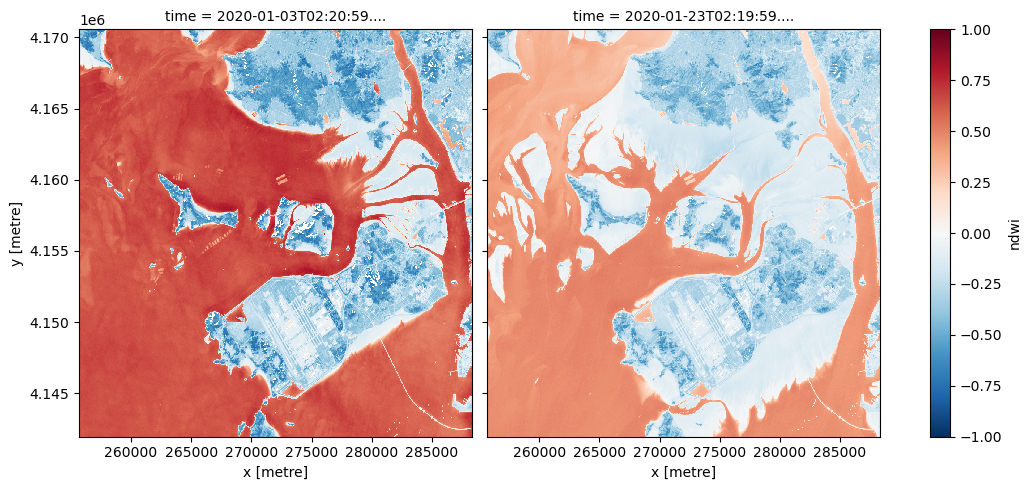

In [6]:
satellite_ds.ndwi.isel(time=[0, 5]).plot.imshow(col="time", size=5)

## Generate Intertidal elevation
The `intertidal.elevation.elevation` function performs the intertidal elevation calculation by combining information about patterns of inundation from our loaded satellite data with a time-series of modelled tides.

In the example below, the `windows_n` parameter can be used to trade off between run time and intertidal elevation mapping detail. 
More windows (e.g. `windows_n=100`) produces detailed elevation maps that can capture small differences in intertidal morphology - at the expense of slower run times.
Fewer windows (e.g. `windows_n=50`) will run faster, but produce less smooth, less detailed elevation maps.

<div class="alert alert-info">

**Note:** This analysis can take considerable time for large spatial extents with extensive intertidal environments. For regional to continental-scale analysis, we recommend breaking up processing into smaller tiles (e.g. 32 x 32 km) that can be run in parallel.

</div>


In [7]:
# Model elevation for each intertidal pixel
ds, _ = elevation(
    satellite_ds,
    windows_n=50,  # see info above
    tide_model=tide_model,
    tide_model_dir=tide_model_dir,
)

2025-10-02 03:51:04 INFO Processing: Modelling tide heights for each pixel


Creating reduced resolution 5000 x 5000 metre tide modelling array
Modelling tides with EOT20
Reprojecting tides into original resolution


2025-10-02 03:51:30 INFO Processing: Masking nodata and adding tide heights to satellite data array
2025-10-02 03:51:31 INFO Processing: Flattening satellite data array and filtering to intertidal candidate pixels


Reducing analysed pixels from 1036998 to 300997 (29.03%)


2025-10-02 03:51:39 INFO Processing: Running per-pixel rolling median


  0%|          | 0/55 [00:00<?, ?it/s]

2025-10-02 03:52:50 INFO Processing: Modelling intertidal elevation


Applying tidal interval interpolation to 200 intervals
Applying rolling mean smoothing with radius 20


2025-10-02 03:52:53 INFO Processing: Modelling intertidal uncertainty
2025-10-02 03:52:57 INFO Processing: Unflattening data back to its original spatial dimensions
2025-10-02 03:52:57 INFO Processing: Cleaning inaccurate upper intertidal pixels
2025-10-02 03:52:57 INFO Processing: Successfully completed intertidal elevation modelling


### Plot outputs

We can now inspect the outputs of our intertidal elevation modelling.
This includes elevation data (measured in metres relative to Mean Sea Level), elevation uncertainty (metres), the correlation between inundation patterns in each pixel and the modelled tide data, and the inundation frequency of each pixel.

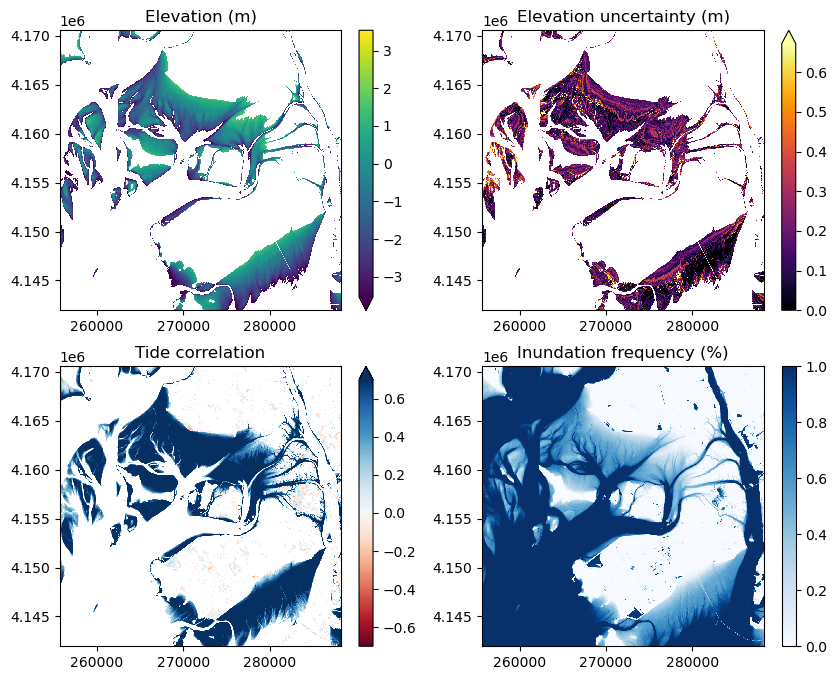

In [8]:
fix, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

ds.elevation.plot.imshow(cmap="viridis", robust=True, ax=axes[0], label=False, add_labels=False)
axes[0].set_title("Elevation (m)")
ds.elevation_uncertainty.plot.imshow(cmap="inferno", robust=True, ax=axes[1], label=False, add_labels=False)
axes[1].set_title("Elevation uncertainty (m)")
ds.qa_ndwi_corr.plot.imshow(cmap="RdBu", vmin=-0.7, vmax=0.7, ax=axes[2], label=False, add_labels=False)
axes[2].set_title("Tide correlation")
ds.qa_ndwi_freq.plot.imshow(cmap="Blues", vmin=0, vmax=1, ax=axes[3], label=False, add_labels=False)
axes[3].set_title("Inundation frequency (%)");

View the data on an interactive map for a closer look:

In [9]:
ds.elevation.odc.explore(robust=True)

## Generate Intertidal exposure
Now that we have generated an intertidal Digital Elevation Model, we can use it to model intertidal exposure (or the percentage of time a pixel is exposed by the tide during the tide cycle).

<div class="alert alert-info">

**Note:** The `modelled_freq` parameter below defines the frequency at which to model tides when calculating how often a pixel is exposed. To keep run times fast we have set it to `3h` (one modelled tide every three hours) - we recommend setting it higher (e.g. `1h` or `30min`) for operational use.

</div>

In [10]:
# Calculate exposure for each elevation pixel
exposure_filters, _ = exposure(
    dem=ds.elevation,
    start_date=start_date,
    end_date=end_date,
    modelled_freq="3h",  # see note above
    tide_model=tide_model,
    tide_model_dir=tide_model_dir,
)

# Add exposure as a new variable in the main dataset
ds["exposure"] = exposure_filters.unfiltered

Creating reduced resolution 5000 x 5000 metre tide modelling array
Modelling tides with EOT20
Returning low resolution tide array
Calculating unfiltered exposure


We can plot our intertidal exposure output - light pixels below are exposed for a large proportion of our time period, while dark pixels are inundated by the tide most of the time:

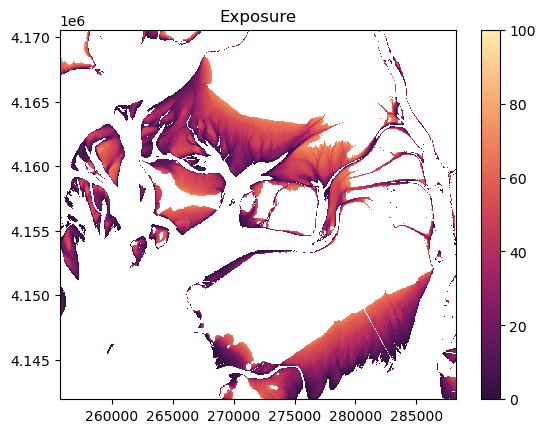

In [11]:
ds.exposure.plot.imshow(cmap=cmocean.cm.matter_r, vmin=0, vmax=100, label=False, add_labels=False)
plt.gca().set_title("Exposure");

## Export outputs

We can now export our outputs to file as GeoTIFF rasters:

In [12]:
# Create output folder if it doesn't exist
output_dir = f"data/interim/{study_area}/{start_date}-{end_date}"
os.makedirs(output_dir, exist_ok=True)

# Prepare data for export
ds["qa_ndwi_freq"] *= 100  # Convert frequency to %

# Prepare for export by correctly setting nodata and dtypes, then
# export to file
ds_prepared = prepare_for_export(ds, output_location=output_dir)

### Close Dask client

In [13]:
client.close()